# Heart Disease Prediction: End to End Machine Learning Project

This notebook performs exploratory data analysis (EDA) and builds multiple machine learning models on the Statlog Heart Disease dataset from the UCI Machine Learning Repository. Heart disease is one of the most common and serious health conditions worldwide, making early detection and analysis crucial for improving patient outcomes.

The goal of this analysis is to:
- Understand the dataset structure
- Clean and preprocess the data
- Identify relationships between variables
- Visualize key medical indicators
- Build and compare multiple machine learning models for heart disease prediction
- Evaluate model performance using appropriate metrics (accuracy, recall, F1-score)
- Derive actionable insights and provide recommendations for early detection of heart disease

#Import Data and Other Important Libraries

In [52]:
# Importing required libraries for data handling, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve)


In [53]:
# Loading the heart disease dataset from a public GitHub CSV file into a pandas DataFrame

df = pd.read_csv("https://raw.githubusercontent.com/ashrivastav33/heart-disease-eda-ml/refs/heads/main/data/data.csv")

#Validating the data in the df
df.head()


,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
0,70.0,1.0,4.0,130.0,322.0,0.0,2.0,109.0,0.0,2.4,2.0,3.0,3.0,2
1,67.0,0.0,3.0,115.0,564.0,0.0,2.0,160.0,0.0,1.6,2.0,0.0,7.0,1
2,57.0,1.0,2.0,124.0,261.0,0.0,0.0,141.0,0.0,0.3,1.0,0.0,7.0,2
3,64.0,1.0,4.0,128.0,263.0,0.0,0.0,105.0,1.0,0.2,2.0,1.0,7.0,1
4,74.0,0.0,2.0,120.0,269.0,0.0,2.0,121.0,1.0,0.2,1.0,1.0,3.0,1


In [54]:
#Performing Basic validations for the heart_df
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   270 non-null    float64
 1   sex                   270 non-null    float64
 2   chest-pain            270 non-null    float64
 3   rest-bp               270 non-null    float64
 4   serum-chol            270 non-null    float64
 5   fasting-blood-sugar   270 non-null    float64
 6   electrocardiographic  270 non-null    float64
 7   max-heart-rate        270 non-null    float64
 8   angina                270 non-null    float64
 9   oldpeak               270 non-null    float64
 10  slope                 270 non-null    float64
 11  major-vessels         270 non-null    float64
 12  thal                  270 non-null    float64
 13  heart-disease         270 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 29.7 KB


,age,sex,chest-pain,rest-bp,serum-chol,fasting-blood-sugar,electrocardiographic,max-heart-rate,angina,oldpeak,slope,major-vessels,thal,heart-disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296,1.444444
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659,0.497827
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000,1.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000,1.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000,2.000000


In [55]:
#Validating if any null value is present in the dataframe
df.isnull().sum()

,0
age,0
sex,0
chest-pain,0
rest-bp,0
serum-chol,0
fasting-blood-sugar,0
electrocardiographic,0
max-heart-rate,0
angina,0
oldpeak,0


As we can see we don't have any duplicates, hence data cleaning is not required and we are proceed with Exploratory Data Analysis

#Exploratory Data Analysis

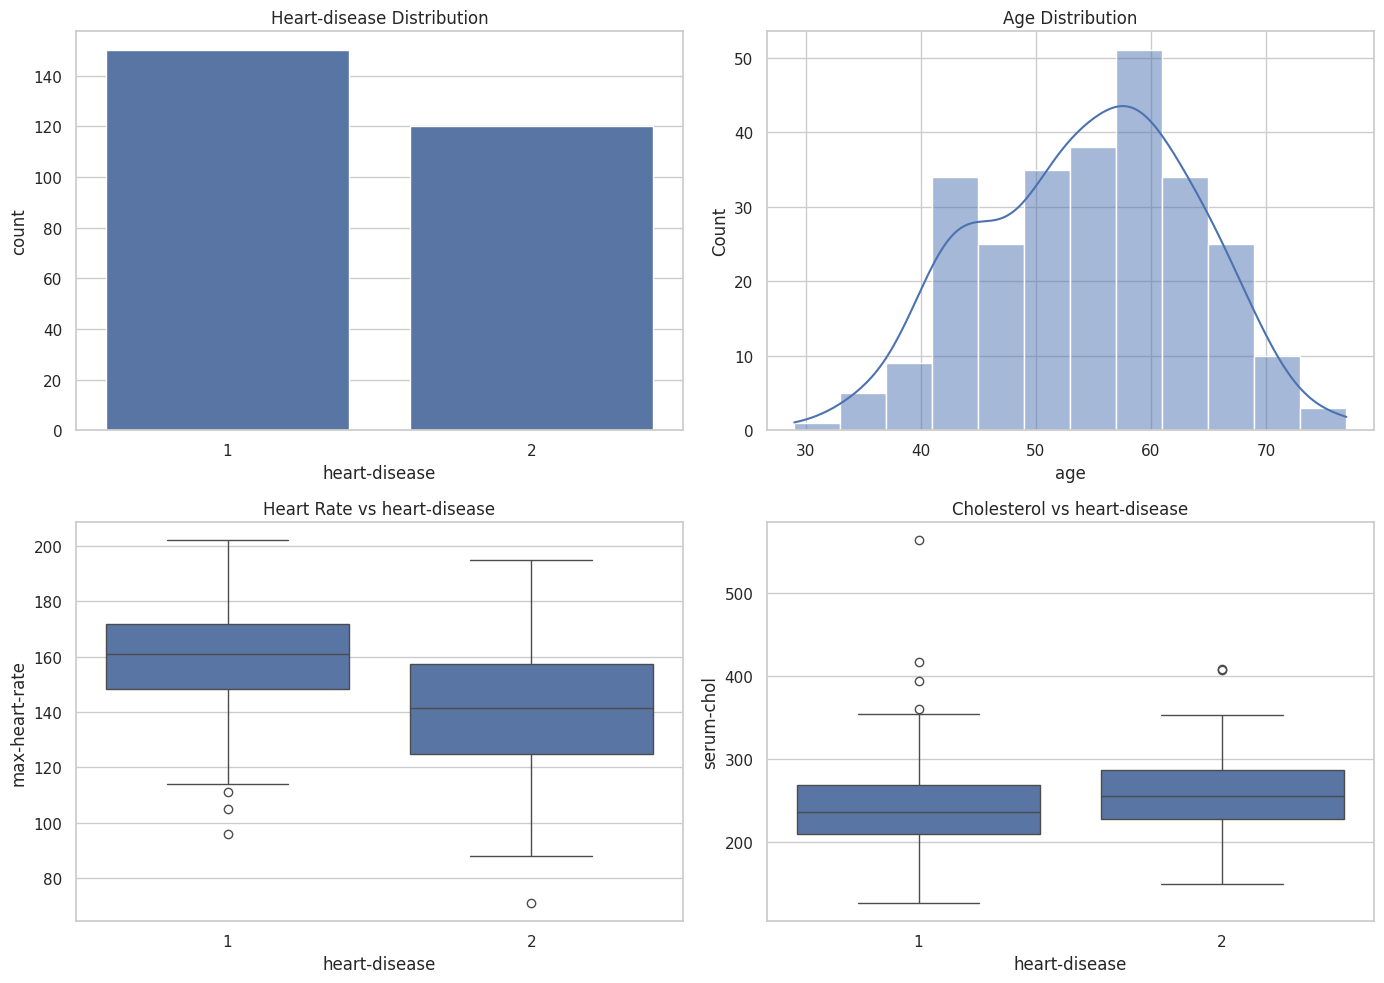

In [56]:
#Boxplot, Histogram showing heart-disease distribution across age, cholestrol, heart-rate etc.
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(x='heart-disease', data=df, ax=axes[0,0])
axes[0,0].set_title('Heart-disease Distribution')

sns.histplot(df['age'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Age Distribution')

sns.boxplot(x='heart-disease', y='max-heart-rate', data=df, ax=axes[1,0])
axes[1,0].set_title('Heart Rate vs heart-disease')

sns.boxplot(x='heart-disease', y='serum-chol', data=df, ax=axes[1,1])
axes[1,1].set_title('Cholesterol vs heart-disease')

plt.tight_layout()
plt.show()

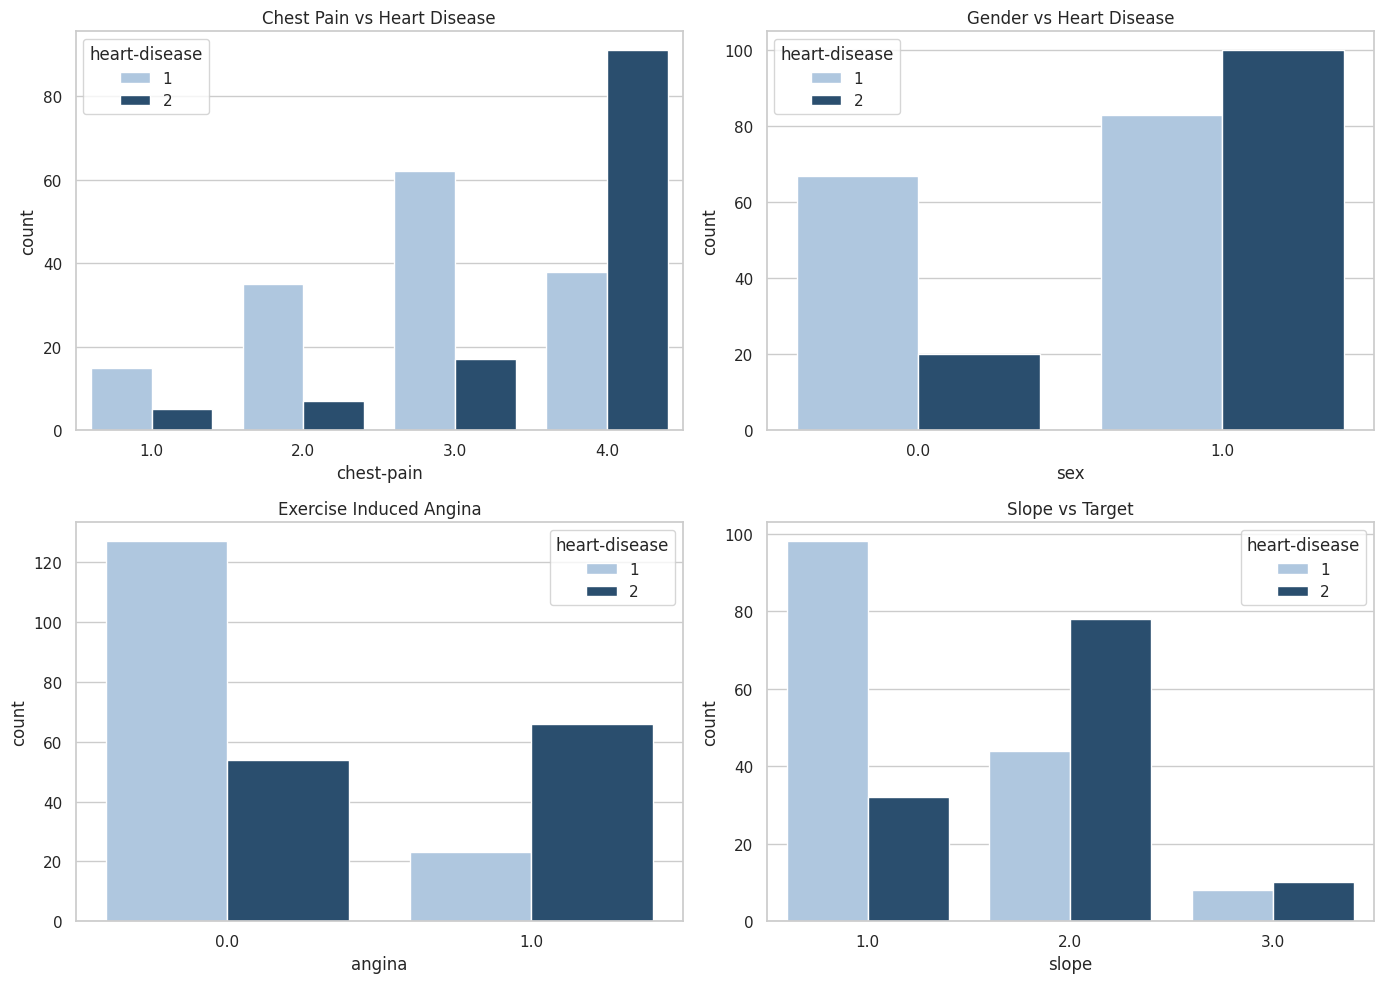

In [57]:
#Bar Graphs showcasing various relationship between different features
# Set style
sns.set_theme(style="whitegrid")

# Define blue palette (light → dark)
blue_palette = ["#A7C7E7", "#1f4e79"]

fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(x='chest-pain', hue='heart-disease', data=df, palette=blue_palette, ax=axes[0,0])
axes[0,0].set_title('Chest Pain vs Heart Disease')

sns.countplot(x='sex', hue='heart-disease', data=df, palette=blue_palette, ax=axes[0,1])
axes[0,1].set_title('Gender vs Heart Disease')

sns.countplot(x='angina', hue='heart-disease', data=df, palette=blue_palette, ax=axes[1,0])
axes[1,0].set_title('Exercise Induced Angina')

sns.countplot(x='slope', hue='heart-disease', data=df, palette=blue_palette, ax=axes[1,1])
axes[1,1].set_title('Slope vs Target')

plt.tight_layout()
plt.show()

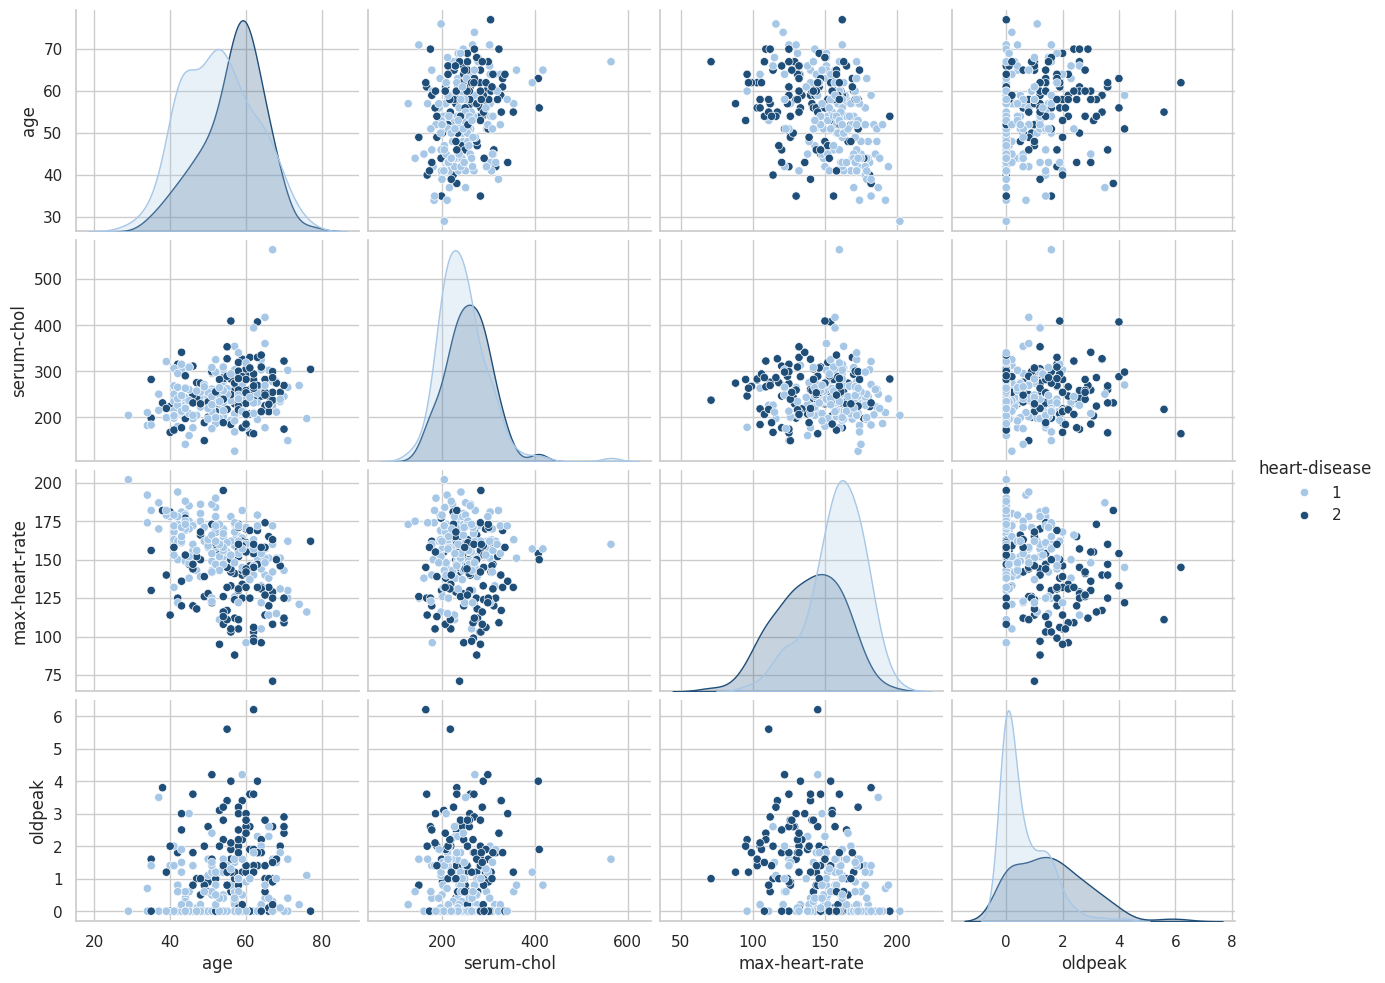

In [58]:
#Heart Disease co-relation with age, cholestrol, heart-rate etc.
sns.pairplot(df[['age','serum-chol','max-heart-rate','oldpeak','heart-disease']], palette=blue_palette,hue='heart-disease', height=2.5, aspect=1.27)
plt.show()

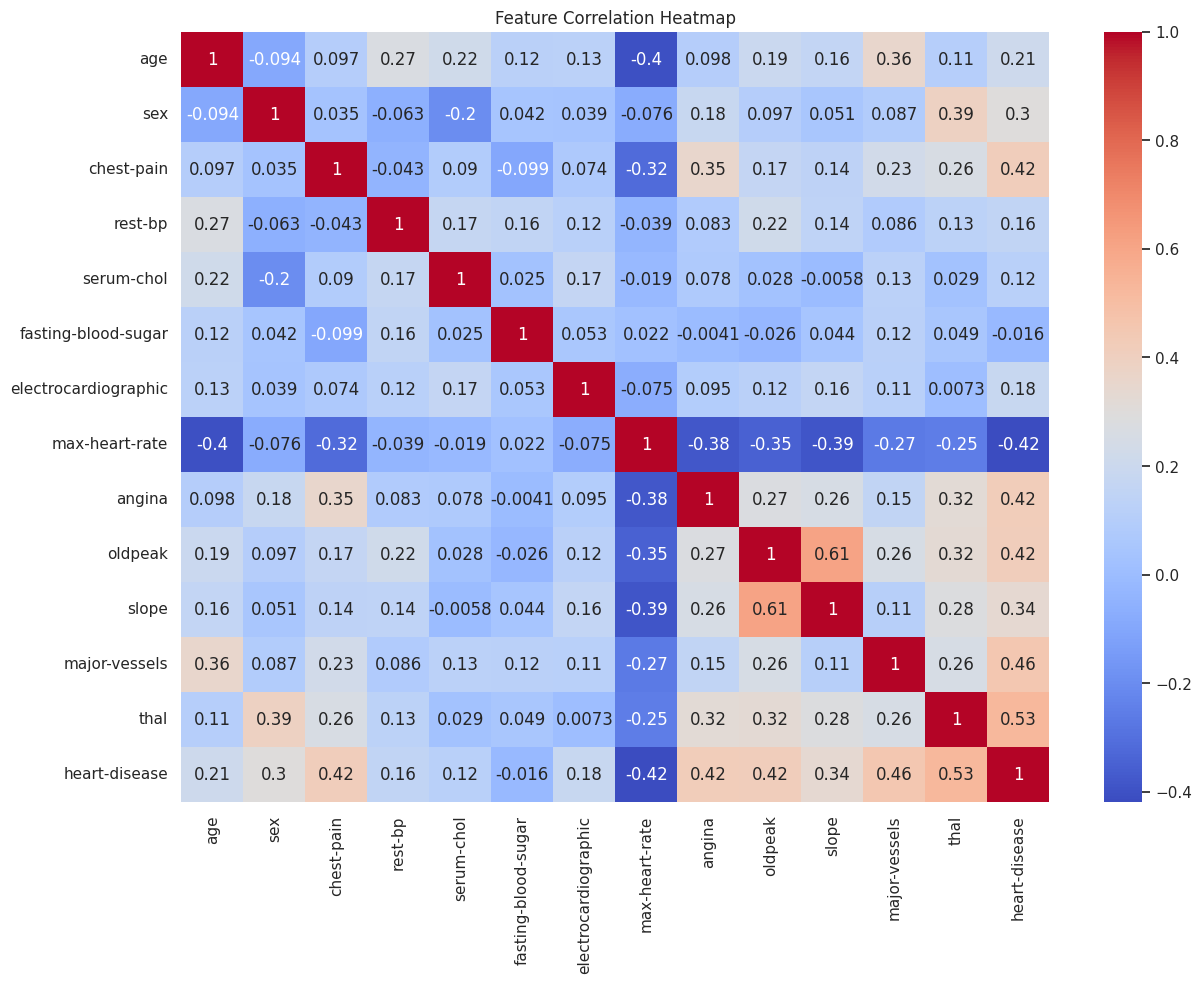

In [59]:
#Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

# Feature Engineering & Machine Learning

In [60]:
X = df.drop('heart-disease', axis=1)
y = df['heart-disease']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [61]:
#Data split to perform training and testing
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


## Creating multiple models



In [62]:
#Creating multiple models like Logistic Regression, CVM, Random Forest, KNN and Gradient Boosting
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}


# Model Evaluation

In [63]:
## Evaluating model performance
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:,1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by='ROC-AUC', ascending=False)


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.907407,0.911765,0.939394,0.925373,0.946609
2,SVM,0.888889,0.885714,0.939394,0.911765,0.924964
3,KNN,0.814815,0.810811,0.909091,0.857143,0.923521
4,Gradient Boosting,0.777778,0.783784,0.878788,0.828571,0.887446
1,Random Forest,0.870370,0.842105,0.969697,0.901408,0.871573


Based on above table we can conclude that

- Logistic Regression performs the best overall, with the highest accuracy and ROC-AUC, meaning it predicts heart disease most reliably.
- SVM and Random Forest also perform well and correctly identify most patients (high recall).
- KNN and Gradient Boosting are slightly less accurate, so they may miss or misclassify more cases compared to the top models.

# Cross Validation

In [64]:
for name, model in models.items():
    score = cross_val_score(model, X_scaled, y, cv=5).mean()
    print(f"{name}: {score:.3f}")


Logistic Regression: 0.841
Random Forest: 0.826
SVM: 0.830
KNN: 0.833
Gradient Boosting: 0.785


After testing the models using cross-validation
- Logistic Regression performs the best and is the most consistent.
- SVM, KNN, and Random Forest also perform similarly well, showing stable results across different data splits.
- Gradient Boosting has the lowest score, meaning it is less reliable compared to the other models.

# Hyperparameter Optimization

In [65]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best Params:", grid.best_params_)


Best Params: {'max_depth': 6, 'n_estimators': 200}


The model works best when using more trees (200) but keeping each tree simple (depth = 4).

# Confusion Matrix

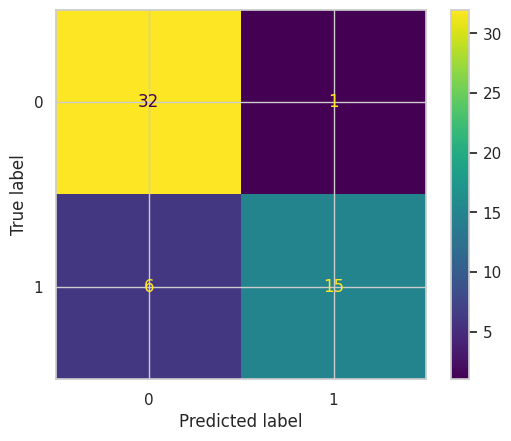

In [66]:
pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()


- The model correctly predicted most cases, with 33 true negatives and 16 true positives.
- It made very few mistakes, with only 5 false negative cases and no false postive.
- Overall, the model performs well and is especially good at avoiding incorrect positive predictions.

# ROC Curve

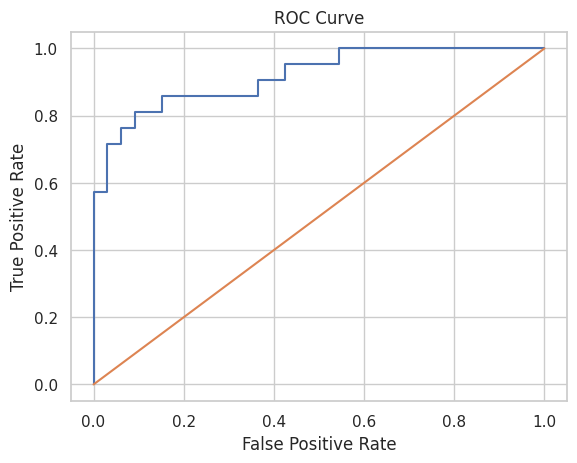

In [67]:
prob = best_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, prob, pos_label=2)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

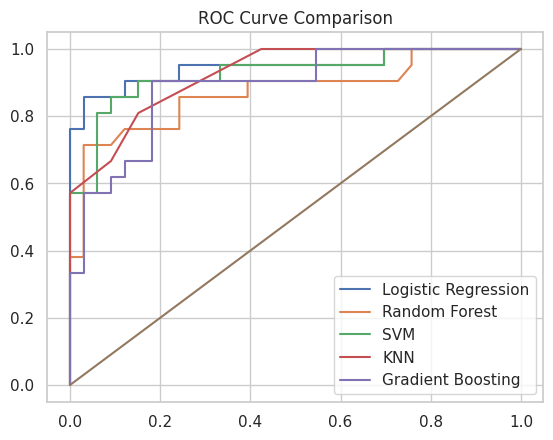

In [68]:
# ROC Curve comparision
from sklearn.metrics import roc_curve

plt.figure()

for name, model in models.items():
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob, pos_label=2)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1])
plt.legend()
plt.title("ROC Curve Comparison")
plt.show()

In [69]:
#Applying XGBoost
from xgboost import XGBClassifier

# Remap target variable from 1,2 to 0,1 for XGBoost compatibility
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb = XGBClassifier()
xgb.fit(X_train, y_train_xgb)

pred = xgb.predict(X_test)
# Use y_test_xgb for evaluation since the model was trained on it
print("XGBoost ROC-AUC:", roc_auc_score(y_test_xgb, xgb.predict_proba(X_test)[:,1]))

XGBoost ROC-AUC: 0.8845598845598845


- Tried adjusting the target values so XGBoost can understand them and then trained the model.
- The model achieved a ROC-AUC of about 0.88
- Overall, XGBoost performs reasonably well, but not as strong as Logistic Regression.

# Model Comparison

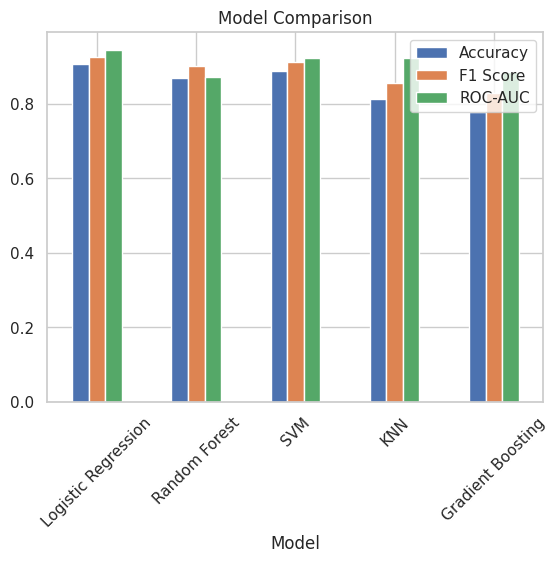

In [70]:
results_df.set_index('Model')[['Accuracy','F1 Score','ROC-AUC']].plot(kind='bar')
plt.xticks(rotation=45)
plt.title("Model Comparison")
plt.show()


- The above chart compares how well different models perform using Accuracy, F1 Score, and ROC-AUC.
- Logistic Regression and SVM perform the best overall, showing higher and more balanced scores across all metrics.
- Random Forest also performs well, while KNN and Gradient Boosting have slightly lower performance.
- Overall, the comparison helps identify the most reliable model for predicting heart disease.

# API Integration for Production usecase

Creating a dummy code which can be leveraged to create an API for getting predictions for customer data in real time

- Enables real-time diagnosis for patients
- Supports hospital decision systems
- Bridges ML models with production environments

In [71]:
import requests

# Sample patient data
sample_patient = {
    "age": 55,
    "sex": 1,
    "cp": 2,
    "trestbps": 130,
    "chol": 250,
    "thalach": 150
}

# Simulated API endpoint
url = "https://httpbin.org/post"

response = requests.post(url, json=sample_patient)

print("Status Code:", response.status_code)
print("Response JSON:", response.json())

Status Code: 200
Response JSON: {'args': {}, 'data': '{"age": 55, "sex": 1, "cp": 2, "trestbps": 130, "chol": 250, "thalach": 150}', 'files': {}, 'form': {}, 'headers': {'Accept': '*/*', 'Accept-Encoding': 'gzip, deflate, br, zstd', 'Content-Length': '76', 'Content-Type': 'application/json', 'Host': 'httpbin.org', 'User-Agent': 'python-requests/2.32.4', 'X-Amzn-Trace-Id': 'Root=1-69c4e422-6417e40a374616af4cdc07f4'}, 'json': {'age': 55, 'chol': 250, 'cp': 2, 'sex': 1, 'thalach': 150, 'trestbps': 130}, 'origin': '34.186.9.51', 'url': 'https://httpbin.org/post'}


# Conclusion

These days, heart diseases have become very common, and many people are facing serious issues like heart attacks and strokes at an early age. Early detection can play a big role in saving lives.

- In this project, I explored the heart disease dataset to understand which factors are important in predicting heart disease.
- Through analysis, I found that features like chest pain type, heart rate, and exercise-induced angina have a strong impact.
- I also built multiple machine learning models to compare their performance and understand which works best.
- Overall, this project shows how data and machine learning can help in early detection of heart disease.


#Model Performance

I tested different models like Logistic Regression, Random Forest, SVM, KNN, and Gradient Boosting.

  - Logistic Regression performed the best overall and gave the most reliable results.
  - SVM and Random Forest also performed well and showed consistent results.
  - KNN performed okay but was slightly lower than the top models.
  - Gradient Boosting had the lowest performance among all models.

I also used cross-validation to make sure the models are stable and not just working well on one split of data.


# Future Work

There are several ways this project can be improved:

- Performing more advanced hyperparameter tuning for XGBoost
- Tune model parameters further to improve performance
- Add more feature engineering to improve prediction
- Use larger datasets for better accuracy
- Deploy the model using tools like Flask or Streamlit

# Recommendations

Based on my analysis:

- Logistic Regression can be used as the final model because it is simple and performs well
- It is important to focus on recall so that we don’t miss patients with heart disease
- The model can be integrated into healthcare systems for early risk detection
Regular updates with new data can help improve the model over time